In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
from IPython.display import display
import seaborn as sns
np.set_printoptions(precision=3, floatmode='fixed')
plt.rcParams["font.size"] = 14
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["axes.grid"] = True
pd.options.display.float_format = "{:.3f}".format
pd.set_option("display.max_columns", None)

from pprint import pprint

import pymc as pm
import arviz as az

print(f"Running on PyMC v{pm.__version__}")
print(f"Running on ArviZ v{az.__version__}")

/home/inoue/MyGithub/Book_BayesInference/.venv/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Running on PyMC v5.27.0
Running on ArviZ v0.23.0


最尤推定

Text(0.5, 1.0, '尤度関数')

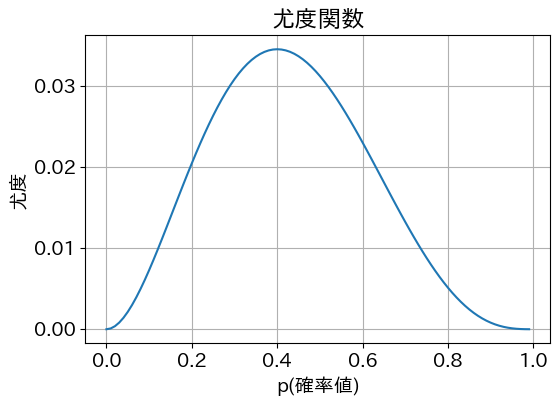

In [2]:
def lh(p):
    return p ** 2 * (1-p) ** 3

p = np.arange(0, 1, 0.01)

plt.rcParams['figure.figsize'] = (6,4)
plt.plot(p, lh(p))
plt.xlabel("p(確率値)")
plt.ylabel("尤度")
plt.title("尤度関数")

勾配降下法で最尤推定値を求める

In [3]:
import torch

def log_lh(p):
    # 対数尤度関数
    return (2 * torch.log(p) + 3 * torch.log(1-p))

num_epochs = 40
lr = 0.01

# パラメータ初期値p=0.1
p = torch.tensor(0.1, dtype=torch.float32, requires_grad=True)

logs = np.zeros((0,3))
for epoch in range(num_epochs):
    loss = -log_lh(p) # 損失関数
    loss.backward()   # 勾配計算
    with torch.no_grad():
        p -= lr * p.grad # パラメータ修正
        p.grad.zero_()   # 勾配値の初期化
    log = np.array([epoch, p.item(), loss.item()]).reshape(1, -1)
    logs = np.vstack([logs, log])


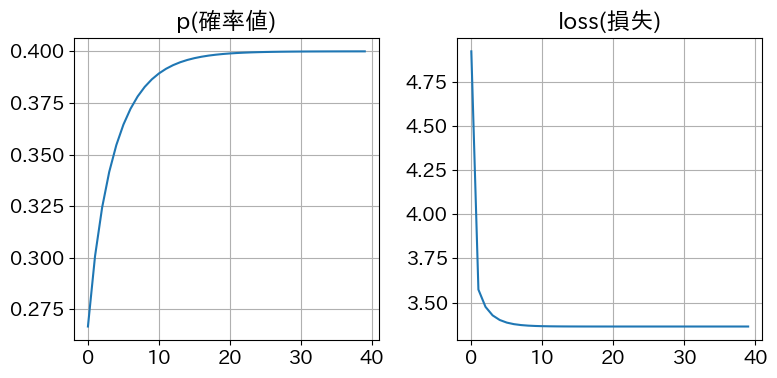

In [4]:
plt.rcParams["figure.figsize"] = (8,4)
fig, axes = plt.subplots(1,2)
axes[0].plot(logs[:,0], logs[:,1])
axes[0].set_title("p(確率値)")
axes[1].plot(logs[:,0], logs[:,2])
axes[1].set_title("loss(損失)")
plt.tight_layout()
plt.show()

ベイズ推論

In [5]:
# データ（観測値）準備
X = np.array([1, 0, 0, 1, 0])
print(X)

[1 0 0 1 0]


In [6]:
# 確率モデル定義

model1 = pm.Model()

with model1:
    # pm.Uniform: 一様分布
    p = pm.Uniform('p', lower=0, upper=1.0)

    # pm.Bernoulli: ベルヌーイ分布
    X_obs = pm.Bernoulli("X_obs", p=p, observed=X)


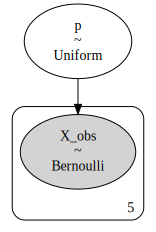

In [7]:
# 確率モデルの可視化
g = pm.model_to_graphviz(model1)
display(g)

In [8]:
# サンプリング(MCMC)
with model1:
    idata1_1 = pm.sample(
        # 乱数系列の数(デフォルト2)
        chains=3,
        # 捨てるサンプル数(デフォルト1000)
        tune=2000,
        # 取得するサンプル数(デフォルト1000)
        draws=2000,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [p]


Output()

Sampling 3 chains for 2_000 tune and 2_000 draw iterations (6_000 + 6_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [9]:
# デフォルト設定でサンプリング
with model1:
    idata1_2 = pm.sample(random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


plot_trace関数

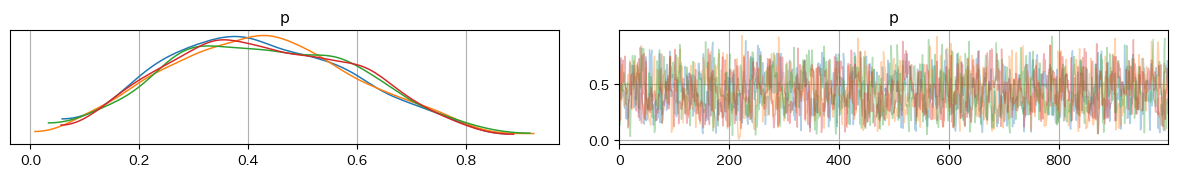

In [10]:
az.plot_trace(idata1_2, compact=False)
plt.tight_layout()

plot_posterior関数

Text(0.5, 1.0, 'ベイズ推論結果 初期版')

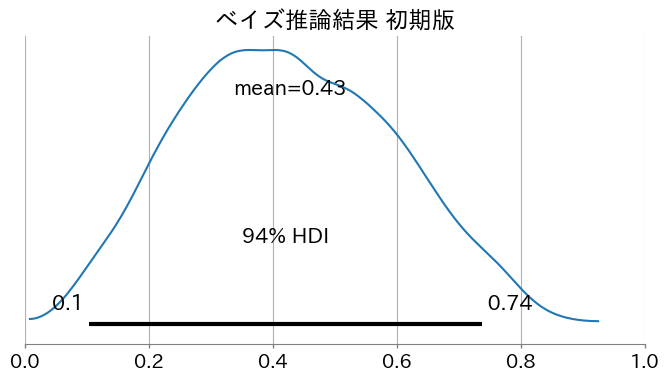

In [11]:
ax = az.plot_posterior(idata1_2)
ax.set_xlim(0,1)
ax.set_title("ベイズ推論結果 初期版")

summary関数

In [12]:
summary1_2 = az.summary(idata1_2)
display(summary1_2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.427,0.174,0.104,0.737,0.004,0.002,1606.000,2514.000,1.000


二項分布バージョン

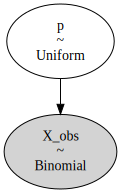

In [13]:
model2 = pm.Model()

with model2:
    p = pm.Uniform("p", lower=0.0, upper=1.0)

    # ベルヌーイ分布 -> 二項分布
    X_obs = pm.Binomial('X_obs', p=p, n=5, observed=2)

g = pm.model_to_graphviz(model2)
display(g)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.427,0.174,0.104,0.737,0.004,0.002,1606.000,2514.000,1.000


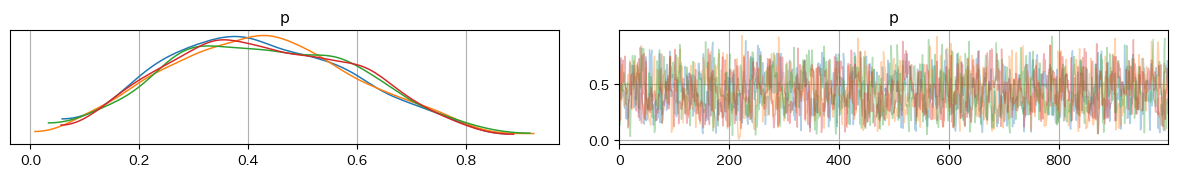

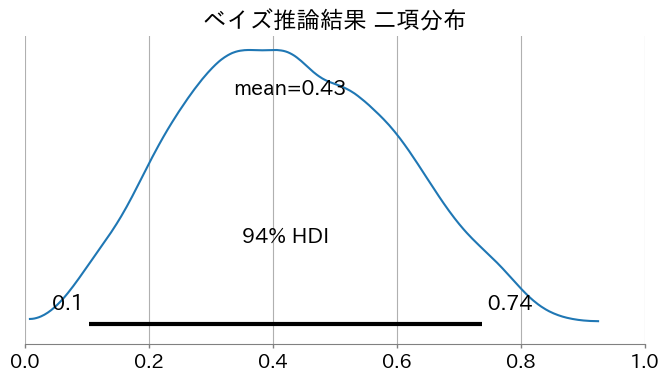

In [14]:
with model2:
    idata1_2 = pm.sample(random_seed=42)

az.plot_trace(idata1_2, compact=False)
plt.tight_layout()

ax = az.plot_posterior(idata1_2)
ax.set_xlim(0,1)
ax.set_title("ベイズ推論結果 二項分布")

summary1_2 = az.summary(idata1_2)
display(summary1_2)

回数を増やす

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.404,0.068,0.281,0.534,0.002,0.001,1635.000,2691.000,1.000


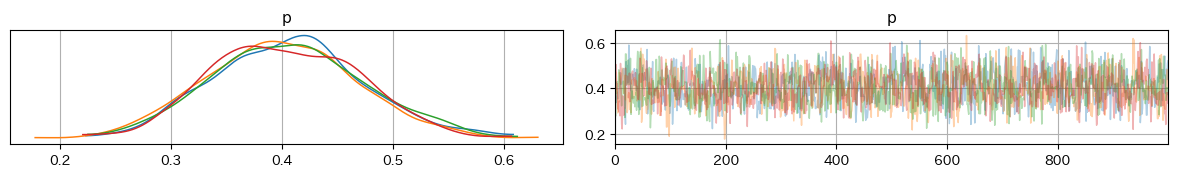

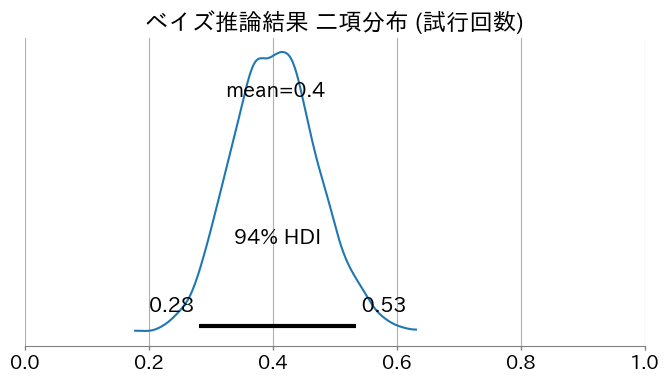

In [18]:
model3 = pm.Model()

with model3:
    p = pm.Uniform('p', lower=0.0, upper=1.0)
    X_obs = pm.Binomial("X_obs", p=p, n=50, observed=20)

with model3:
    idata3 = pm.sample(random_seed=42)

az.plot_trace(idata3, compact=False)
plt.tight_layout()

ax = az.plot_posterior(idata3)
ax.set_xlim(0,1)
ax.set_title("ベイズ推論結果 二項分布 (試行回数)")

summary3 = az.summary(idata3)
display(summary3)

事前分布を変更

In [19]:
model4 = pm.Model()

with model4:
    p = pm.Uniform('p', lower=0.1, upper=0.9)
    X_obs = pm.Binomial("X_obs", p=p, n=5, observed=2)
    idata4 = pm.sample(random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.442,0.166,0.135,0.734,0.004,0.002,1519.000,1978.000,1.000


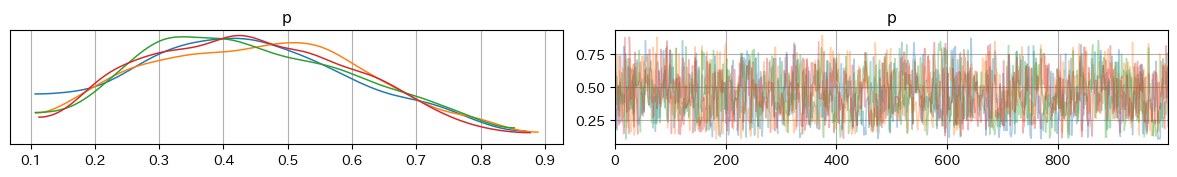

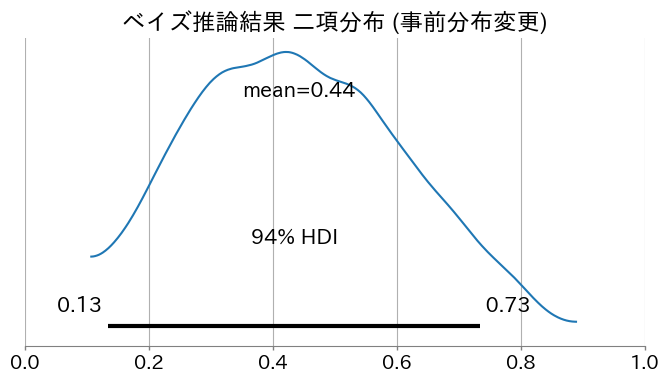

In [20]:
az.plot_trace(idata4, compact=False)
plt.tight_layout()

ax = az.plot_posterior(idata4)
ax.set_xlim(0,1)
ax.set_title("ベイズ推論結果 二項分布 (事前分布変更)")

summary4 = az.summary(idata4)
display(summary4)

ベータ分布で直接確率分布を求める

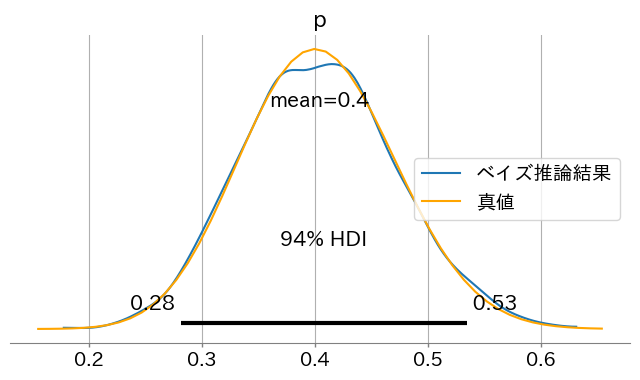

In [21]:
# 実は真の確率分布がベータ分布とわかるので，分布を直接定義
from scipy import stats
# 50回中20回成功
alpha = 20 + 1
beta = 30 + 1
true_beta = stats.beta(alpha, beta)

# ベイズ推論結果の可視化
ax = az.plot_posterior(idata3)
ax.lines[0].set_label("ベイズ推論結果")

# 真のベータ関数の可視化
x = np.linspace(*ax.get_xlim())
ax.plot(x, true_beta.pdf(x), color="orange", label="真値")
ax.legend(loc="center right")